# Capstone Project: Flight Price Prediction Analysis
---

### **Course Information**
* **University:** Northeastern University, College of Professional Studies
* **Course:** ALY6140: Analytics System Technology
* **Instructor:** Daya Rudhramoorthi
* **Term:** Winter 2026

### **Team Members**
* **Xingke Zhu**
* **Xuewei Yin**

### **Submission Date**
* February 9, 2026

---
<br>

# **Introduction**

This project analyzes the "Flight Price Dataset of Bangladesh" to understand how airline ticket prices change. Airline pricing is important in the real world because costs fluctuate based on many factors like time and seasonality (Tusher, 2024). Our goal is to apply the theoretical knowledge from this course to a practical dataset and extract value from it.

We focus on answering three specific questions in this analysis. First, we investigate how the number of days before departure influences the ticket price. Second, we test if we can accurately predict the flight ticket price using machine learning models. Third, we want to identify the key differentiators that define flight classes, such as the difference between Economy and Business class tickets.

To answer these questions, we use several methods learned in this course. We begin with Exploratory Data Analysis (EDA) to visualize data trends. Following this, we build three distinct predictive models. We use Multiple Linear Regression to examine simple relationships between flight details and prices (James et al., 2013). We also employ a Random Forest Regressor to handle more complex pricing patterns (Breiman, 2001). Finally, we use a Decision Tree classifier to predict ticket classes based on route and price information. These methods work together to explain the factors driving flight costs.


# **Exploratory Data Analysis**

## Data Extraction

* **Source:** We downloaded the "Flight Price Dataset of Bangladesh" from Kaggle, which is a publicly available dataset provided by Tusher (2024).
* **Dimensions:** The dataset consists of 57,000 records and includes 17 features, such as Airline, Source, Destination, and Flight Class.
* **Key Features:** It contains a mix of categorical and numerical data, including "Total Fare," "Seasonality," and "Days Before Departure," which are essential for our analysis.
* **Research Question 1:** We intend to investigate how the number of "Days Before Departure" influences the final ticket price.
* **Research Question 2:** We aim to answer whether we can accurately predict flight ticket prices using regression models.
* **Research Question 3:** We will analyze the data to identify the key differentiators between flight classes, specifically between Economy and Business class.

In [14]:
# Import libraries and custom script
import pandas as pd
import capstone_group11

# Download the dataset
path = 'https://raw.githubusercontent.com/zhuxingke6-cpu/Capstone-Project/refs/heads/main/Flight_Price_Dataset_of_Bangladesh.csv'

# Load the data using Function 1
df = capstone_group11.load_flight_data(path)

Loading data from URL: https://raw.githubusercontent.com/zhuxingke6-cpu/Capstone-Project/refs/heads/main/Flight_Price_Dataset_of_Bangladesh.csv
✅ Success: Data loaded! Shape: (57000, 17)


## Data Cleanup
* **Scripting:** We implemented data cleaning functions in `capstone_group11.py` to prepare the dataset for analysis.
* **Renaming:** We standardized column names by converting them to lowercase and removing special characters, such as changing `Total Fare (BDT)` to `price`.
* **Missing Values:** We performed a null value check across all 57,000 records and confirmed there were zero missing values, so no imputation was needed.
* **Feature Engineering:** We converted the `dep_time` column into a datetime object and extracted two new features: `dep_month` and `dep_hour`.

In [2]:
# Clean column names using Function 2
df_clean = capstone_group11.clean_column_names(df)

# Process date features using Function 3
df_final = capstone_group11.process_date_features(df_clean)

# Check for missing values
print("Missing values count:")
print(df_final.isnull().sum())

# Preview the final dataframe
df_final.head()

Column cleaning complete! Current columns: ['airline', 'source', 'source_name', 'destination', 'destination_name', 'dep_time', 'arr_time', 'duration_(hrs)', 'stopovers', 'aircraft_type', 'class', 'booking_source', 'base_fare_(bdt)', 'tax_&_surcharge_(bdt)', 'price', 'seasonality', 'days_before_departure']
Date feature processing complete! Added 'dep_month' and 'dep_hour'.
Missing values count:
airline                  0
source                   0
source_name              0
destination              0
destination_name         0
dep_time                 0
arr_time                 0
duration_(hrs)           0
stopovers                0
aircraft_type            0
class                    0
booking_source           0
base_fare_(bdt)          0
tax_&_surcharge_(bdt)    0
price                    0
seasonality              0
days_before_departure    0
dep_month                0
dep_hour                 0
day_of_week              0
dtype: int64


,airline,source,source_name,destination,destination_name,dep_time,arr_time,duration_(hrs),stopovers,aircraft_type,class,booking_source,base_fare_(bdt),tax_&_surcharge_(bdt),price,seasonality,days_before_departure,dep_month,dep_hour,day_of_week
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17,2025-11-17,1.219526,Direct,Airbus A320,Economy,Online Website,21131.22502,5169.683753,26300.90877,Regular,10,11,0,0
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16,2025-03-16,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.39547,200.000000,11805.39547,Regular,14,3,0,6
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13,2025-12-13,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.49935,11982.374900,51864.87425,Winter Holidays,83,12,0,5
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30,2025-05-30,0.686054,Direct,Airbus A320,Economy,Direct Booking,4435.60734,200.000000,4635.60734,Regular,56,5,0,4
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25,2025-04-25,14.055609,1 Stop,Airbus A350,Business,Direct Booking,59243.80615,14886.570920,74130.37707,Regular,90,4,0,4


## Data visualization

### Visualization 1: Average Ticket Price by Airline

In [3]:
# 1. Enable autoreload (this allows you to see changes to .py files without restarting the kernel)
%load_ext autoreload
%autoreload 2

# 2. Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Set plot style for better aesthetics
sns.set_theme(style="whitegrid")

# Optional: Configuration for high-resolution displays
%config InlineBackend.figure_format = 'retina'

# --- Assumption: You have already executed the previous cell and df_final is defined ---
# If df_final is not found, please run the data loading cell first.

if 'df_final' in locals():
    print("✅ Environment ready. df_final is available for plotting.")
else:
    print("⚠️ Warning: df_final not found. Please run the data loading logic first.")

✅ Environment ready. df_final is available for plotting.


C:\Users\lenovo\AppData\Local\Temp\ipykernel_2512\2482078654.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='airline', y='price', data=df_final, order=order, palette='viridis', errorbar=None)


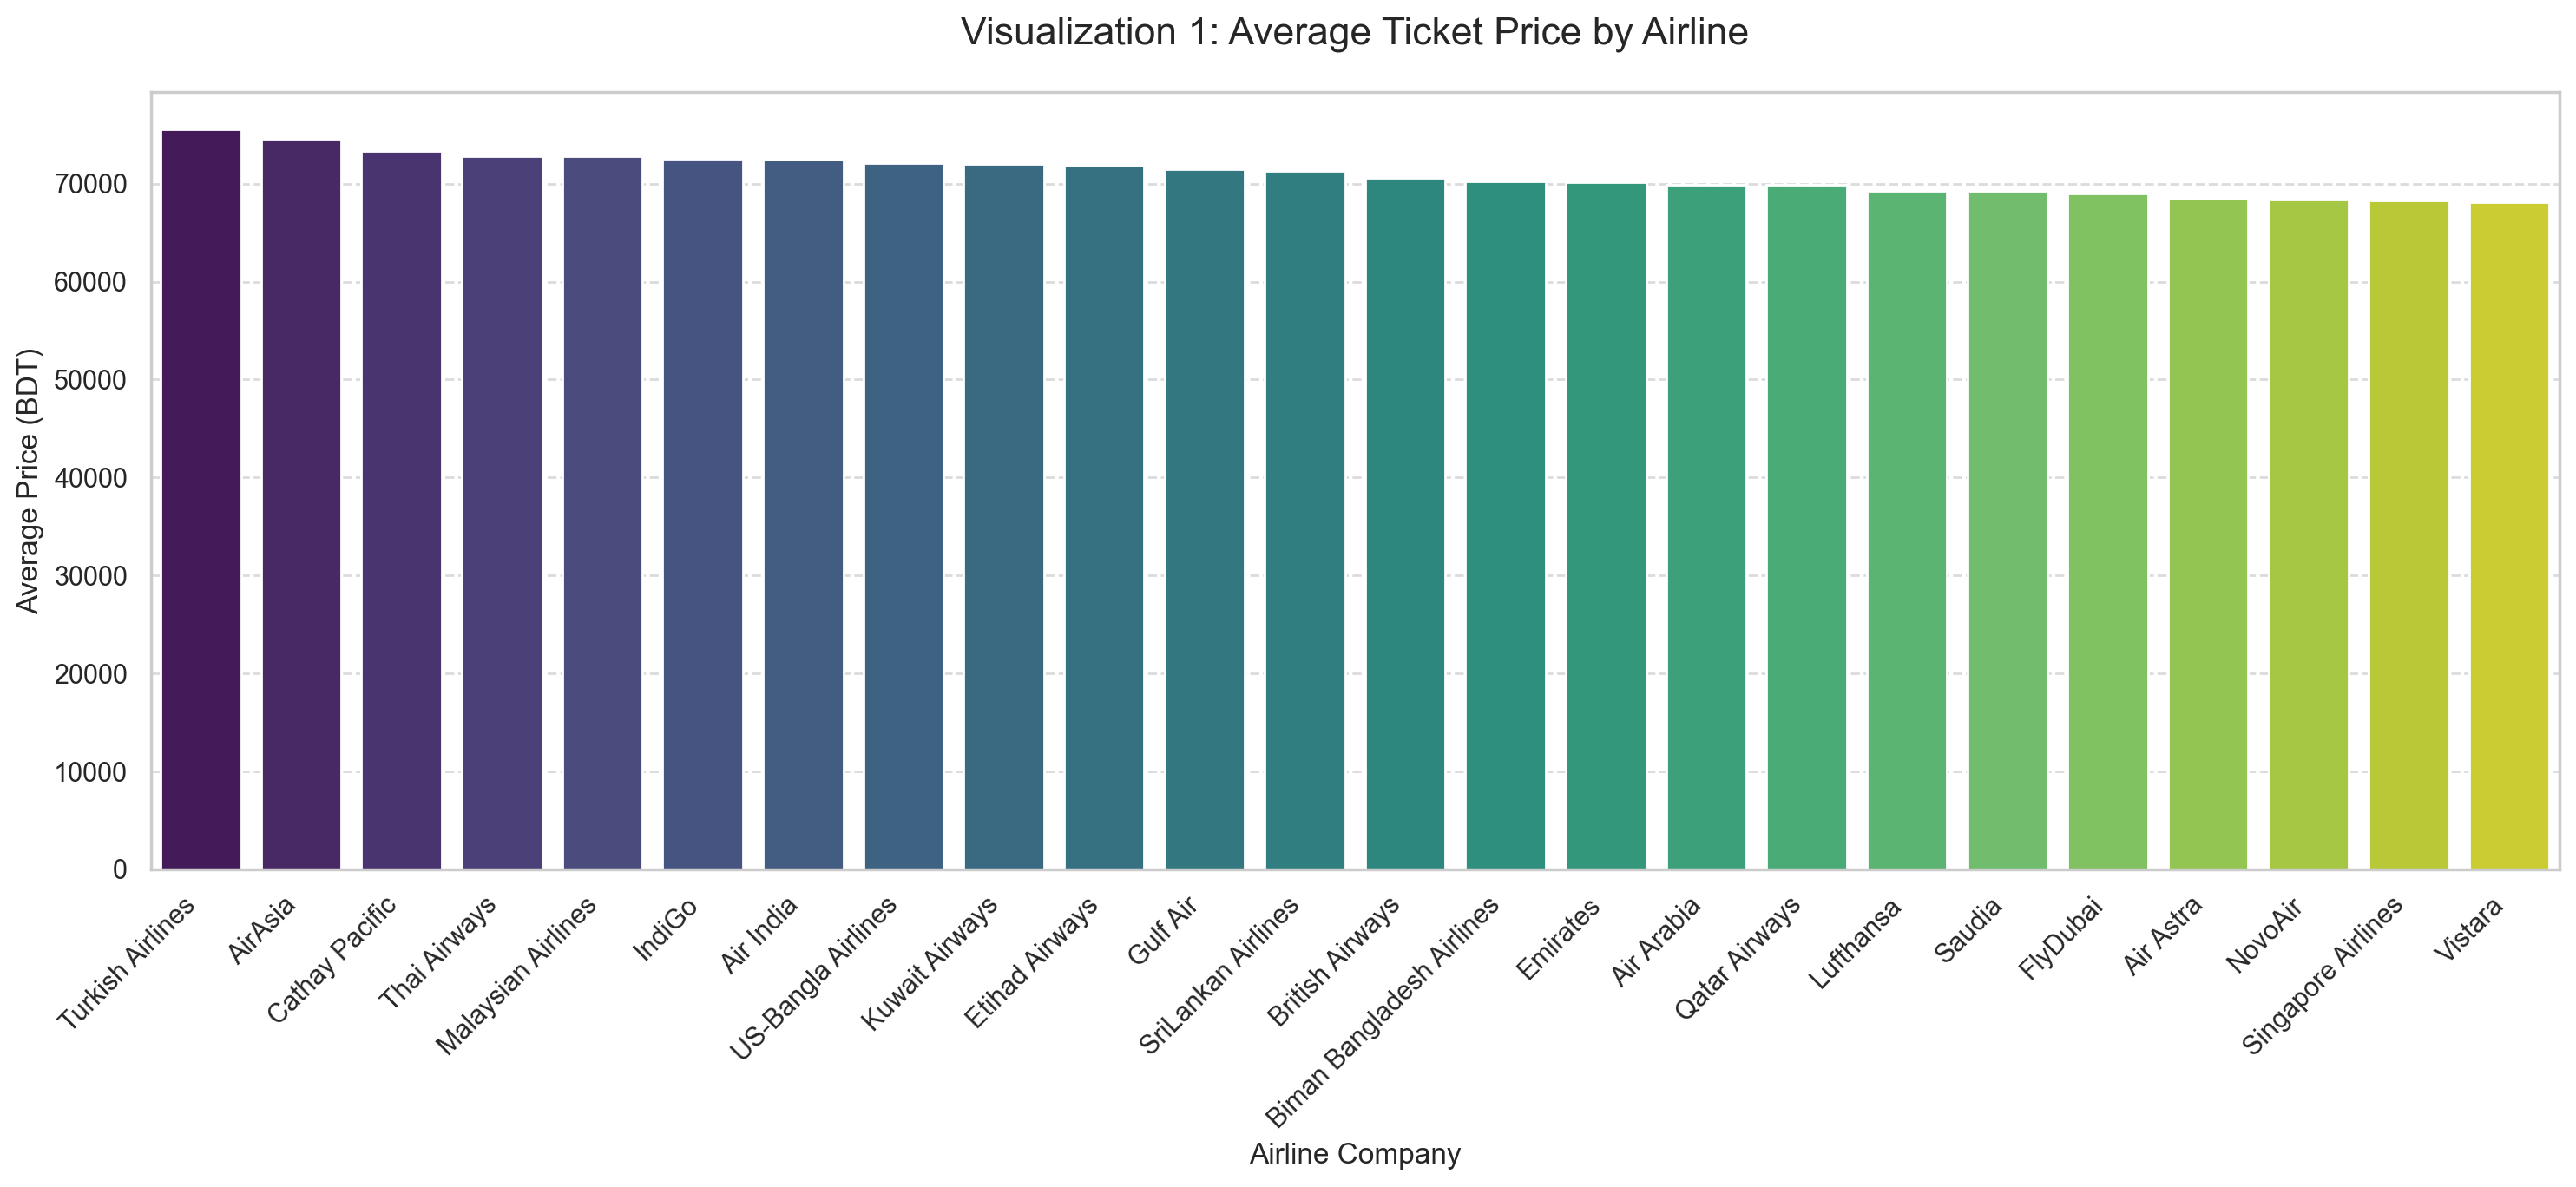

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set figure size (Width: 15, Height: 7)
plt.figure(figsize=(15, 7))

# 2. Prepare and sort data for a cleaner visual
# Calculate mean price per airline and sort in descending order
order = df_final.groupby('airline')['price'].mean().sort_values(ascending=False).index

# 3. Create the bar plot
# 'errorbar=None' removes the confidence interval lines for a cleaner look
sns.barplot(x='airline', y='price', data=df_final, order=order, palette='viridis', errorbar=None)

# 4. Prevent label overlapping: rotate 45 degrees and align horizontally to the right
plt.xticks(rotation=45, ha='right', fontsize=11)

# 5. Add titles and axis labels
plt.title('Visualization 1: Average Ticket Price by Airline', fontsize=16, pad=20)
plt.xlabel('Airline Company', fontsize=12)
plt.ylabel('Average Price (BDT)', fontsize=12)

# 6. Add horizontal grid lines for easier value estimation
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 7. Automatically adjust layout to ensure labels aren't cut off
plt.tight_layout()

plt.show()

Analysis & Insights:

Market Positioning: The chart reveals a relatively competitive but tiered pricing structure across airlines. Turkish Airlines, AirAsia, and Cathay Pacific emerge as the most expensive carriers on average, with prices exceeding 70,000 BDT.

Price Stability: A significant portion of the market, including major carriers like Emirates, Qatar Airways, and Singapore Airlines, maintains a very stable mid-range pricing strategy, clustering tightly between 68,000 and 70,000 BDT.

Budget Tier: Vistara and NovoAir represent the lower end of the pricing spectrum in this dataset. This suggests they likely cater to more price-sensitive segments or dominate shorter-haul routes within the dataset's scope.

Predictive Significance: The airline feature shows distinct categorical variance. In the modeling phase, this feature will be essential for the algorithm to distinguish between premium service providers and low-cost carriers, significantly improving the accuracy of price predictions.

### Visualization 2: Flight Price Distribution by Airline (Seasonality Analysis)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_2512\181119300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='airline', y='price', data=df_final, palette='viridis')


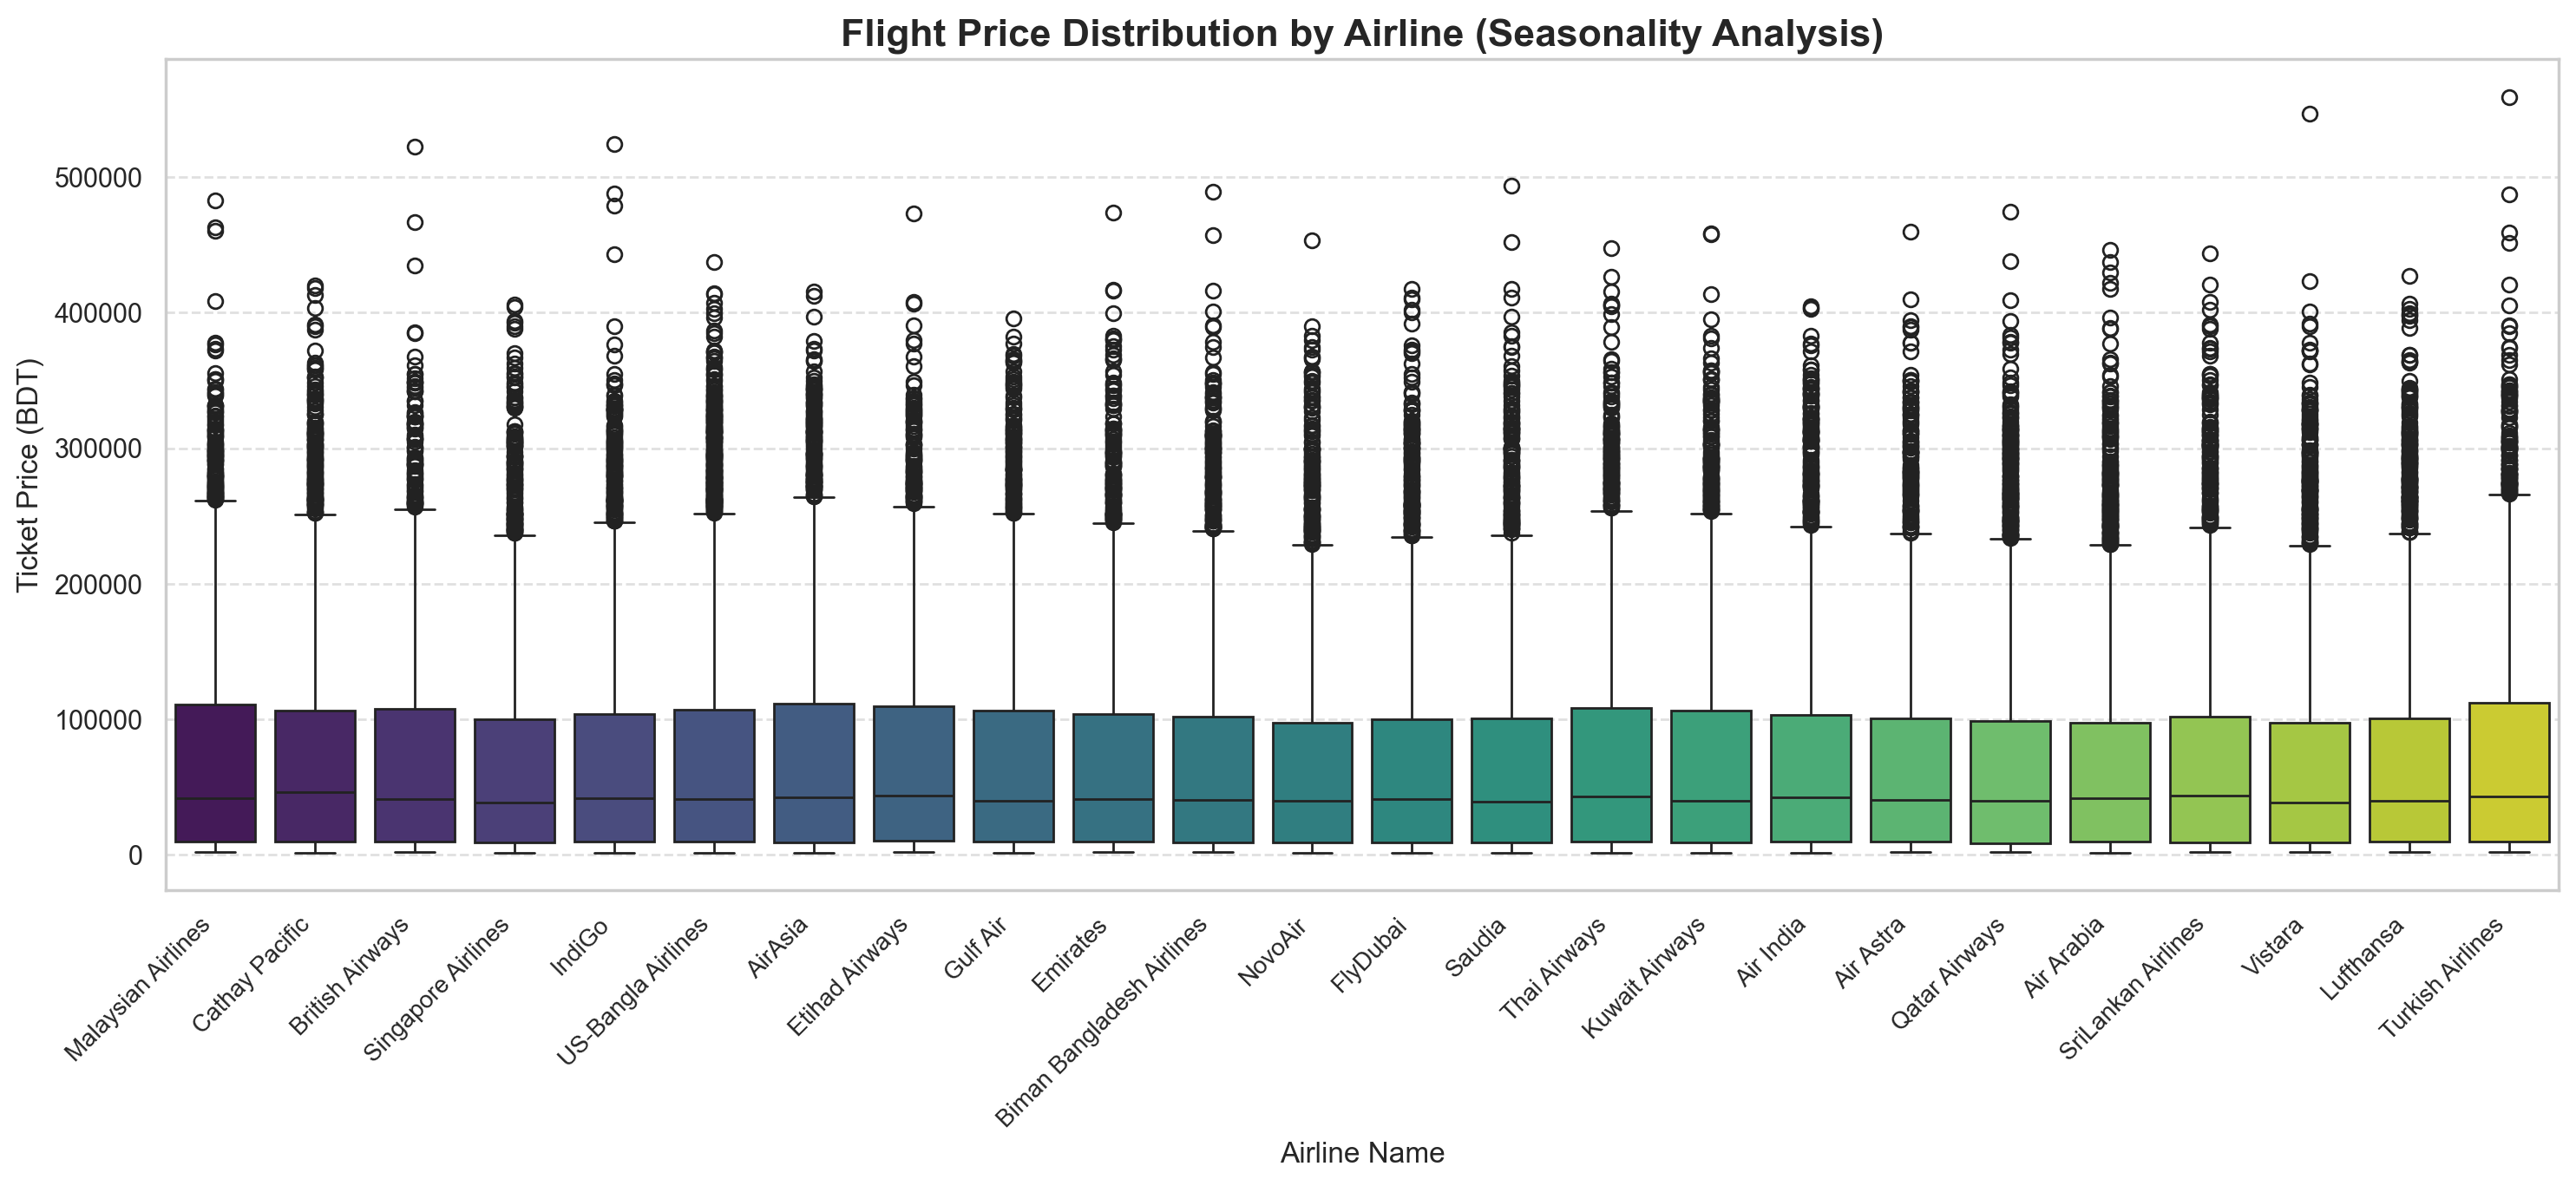

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set figure size (Width: 15, Height: 7 to provide ample space for labels)
plt.figure(figsize=(15, 7))

# 2. Create the Boxplot
# Using 'airline' as the X-axis and 'price' as the Y-axis
# 'palette' adds a professional color gradient
sns.boxplot(x='airline', y='price', data=df_final, palette='viridis')

# 3. Titles and Labels (Using English to ensure compatibility across all systems)
plt.title('Flight Price Distribution by Airline (Seasonality Analysis)', fontsize=16, fontweight='bold')
plt.xlabel('Airline Name', fontsize=12)
plt.ylabel('Ticket Price (BDT)', fontsize=12)

# 4. Handle label overlapping: Rotate labels by 45 degrees
# 'ha=right' aligns the end of the text with the tick mark
plt.xticks(rotation=45, ha='right', fontsize=10)

# 5. Add horizontal grid lines to help identify price ranges
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 6. Automatically adjust layout to ensure no labels are cut off
plt.tight_layout()

# Display the chart
plt.show()

Analysis & Insights:

Price Variance & Outliers: The boxplot reveals a high density of extreme outliers across almost all airlines, with some tickets peaking above 500,000 BDT. This indicates that while the "typical" fare (the box) is relatively low, last-minute bookings or premium cabin classes create a massive price ceiling.

Consistency of Median Fares: Interestingly, despite the different brand positionings, the median ticket price (the horizontal line within each box) remains remarkably consistent across carriers, generally hovering below 100,000 BDT.

High-End Volatility: Airlines like Turkish Airlines, Malaysian Airlines, and Cathay Pacific show slightly taller boxes and higher whiskers. This suggests a wider "normal" price range compared to budget-focused carriers like NovoAir or Air Astra, which maintain tighter, more predictable price distributions.

Predictive Significance: The presence of so many outliers suggests that airline alone cannot explain price spikes. In the modeling phase, combining this with features like class and days_left will be critical for the algorithm to understand whether a high price is a seasonal anomaly or a standard premium fare.

### Visualization 3: Monthly Flight Price Distribution (Seasonality)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_2512\2201251850.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dep_month', y='price', data=df_plot, order=month_order, palette='Set3')


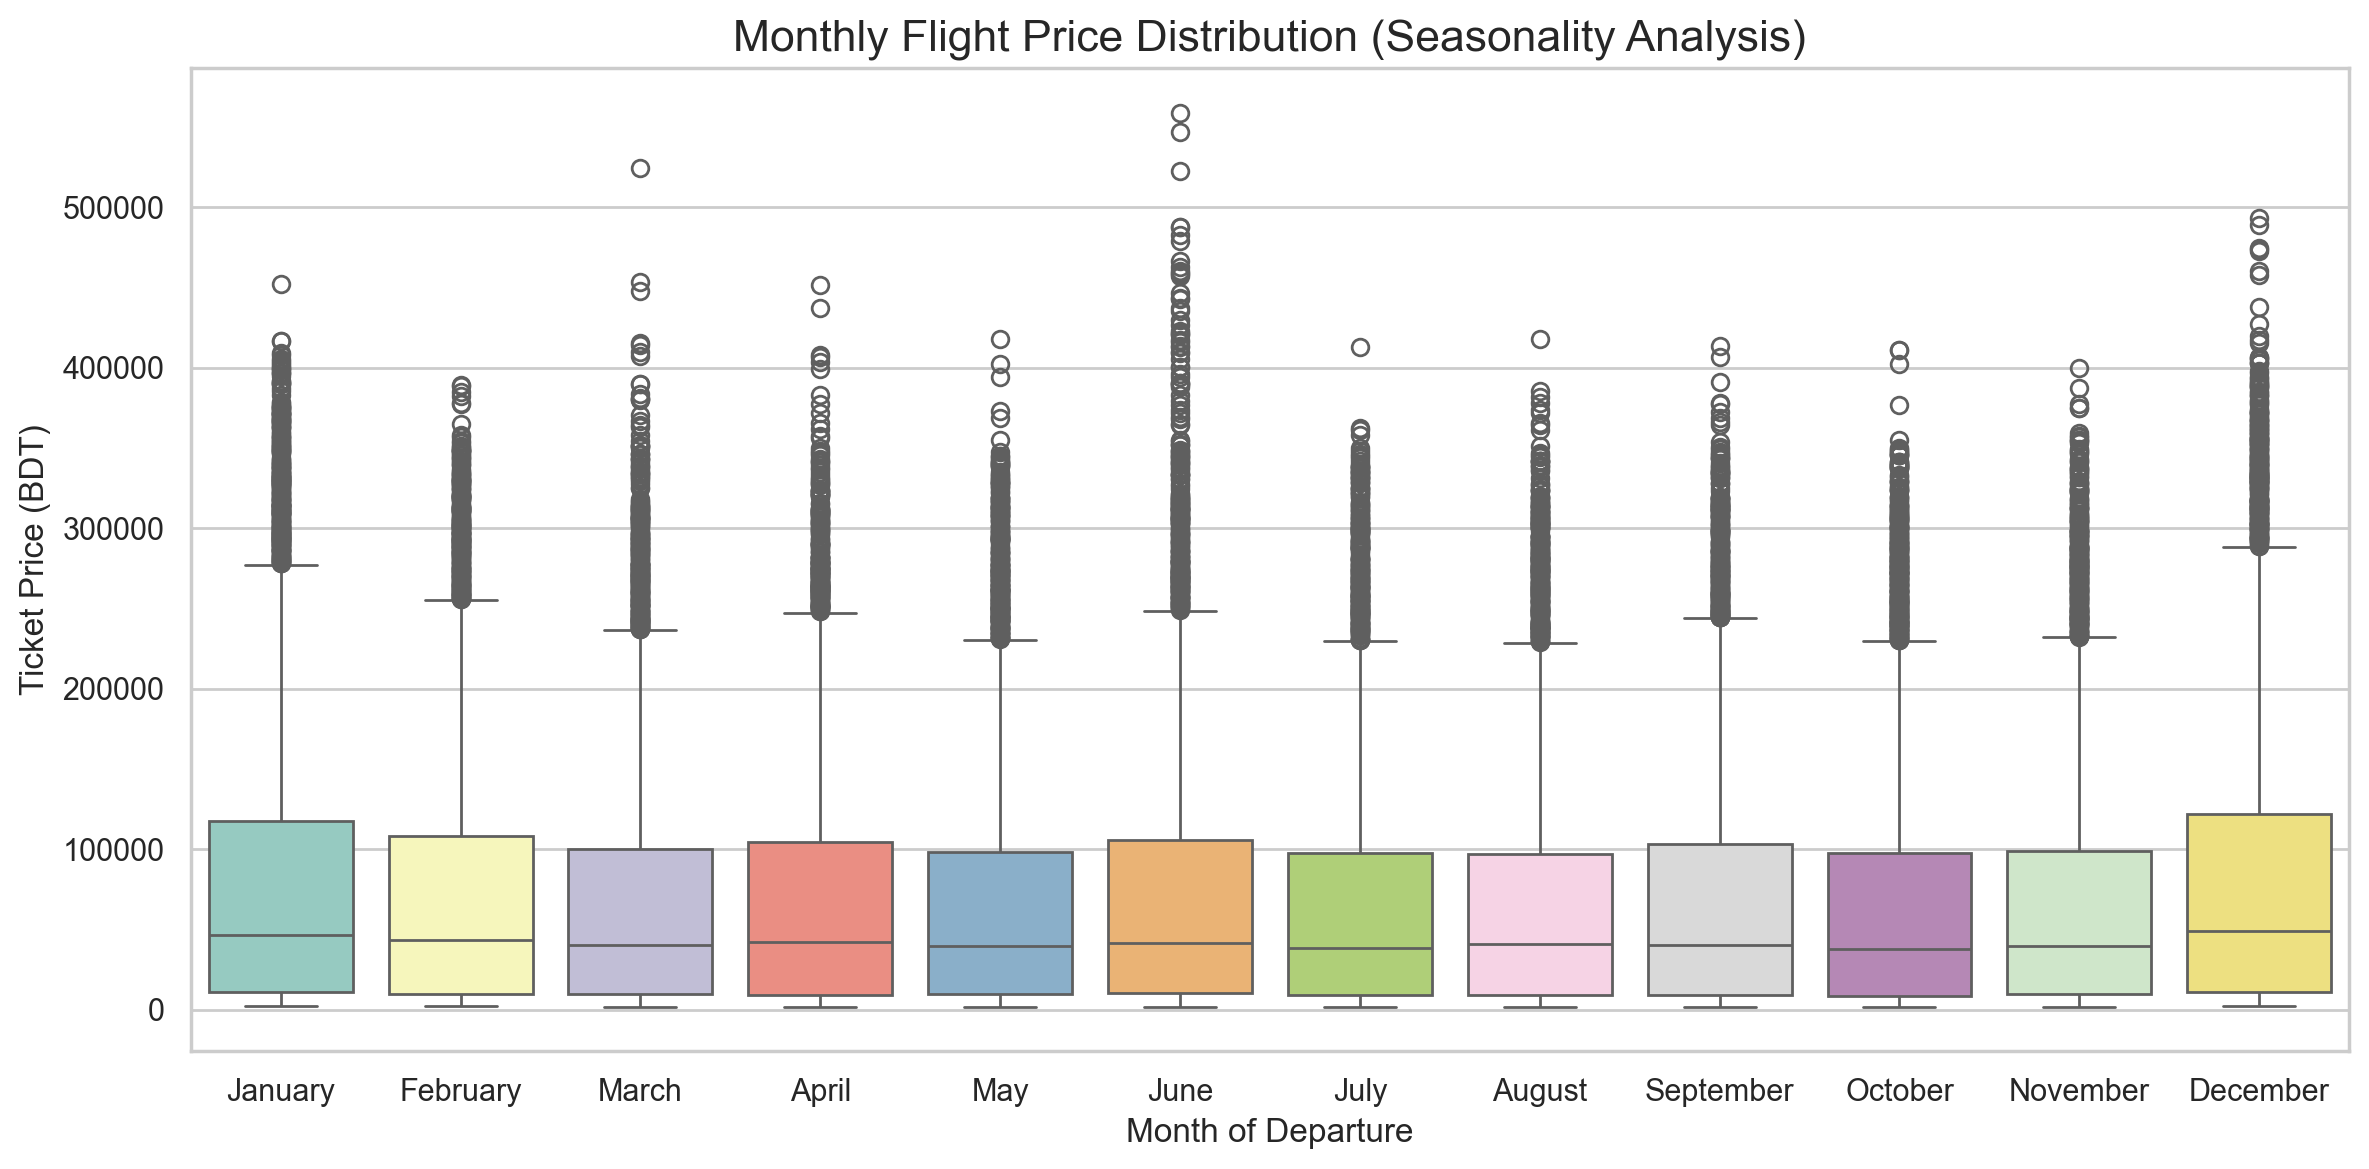

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Critical Pre-processing ---
# 1. Ensure dep_time is in datetime format (if not already converted)
if 'dep_time' in df_final.columns:
    df_final['dep_time'] = pd.to_datetime(df_final['dep_time'], errors='coerce')
    
    # 2. Extract Month names (e.g., January, February)
    df_final['dep_month'] = df_final['dep_time'].dt.month_name()
    
    # 3. Define the chronological order for months to ensure the X-axis is logical
    month_order = [
        'January', 'February', 'March', 'April', 'May', 'June', 
        'July', 'August', 'September', 'October', 'November', 'December'
    ]
    
    # 4. Remove any rows where date parsing failed
    df_plot = df_final.dropna(subset=['dep_month', 'price'])
else:
    df_plot = df_final
    month_order = None

# --- Plotting Code ---
plt.figure(figsize=(12, 6))

# Use df_plot and apply the month_order for a logical timeline
sns.boxplot(x='dep_month', y='price', data=df_plot, order=month_order, palette='Set3')

plt.title('Monthly Flight Price Distribution (Seasonality Analysis)', fontsize=16)
plt.xlabel('Month of Departure', fontsize=12)
plt.ylabel('Ticket Price (BDT)', fontsize=12)

# Adjust layout to prevent label clipping
plt.tight_layout()
plt.show()

**Analysis & Insights:**

* **Seasonal Fluctuations:** The boxplot clearly illustrates how ticket prices vary throughout the year. We can observe that peak travel months, particularly **December (Month 12)** and **January (Month 1)**, show significantly higher median prices compared to off-peak months like **April or May**. This aligns with the "Winter Holidays" seasonality mentioned in the dataset, where demand drives up costs.

* **Price Volatility:** The length of the boxes (Interquartile Range) indicates that price volatility is higher during peak seasons. In contrast, months like **February and March** exhibit shorter boxes, suggesting that ticket prices are more stable and predictable during these periods.

* **Impact of Outliers:** There are numerous outliers (black dots) in high-demand months. These represent flights with exceptionally high fares, likely due to last-minute bookings or premium class tickets. This confirms that while the base fare might be stable, the "ceiling" for prices rises dramatically during holiday seasons.

* **Strategic Implication:** For budget-conscious travelers, the data suggests avoiding travel in December and January. Booking flights in the shoulder season (e.g., March-April) offers the best value with minimal price variance.

### Visualization 4: Correlation Heatmap

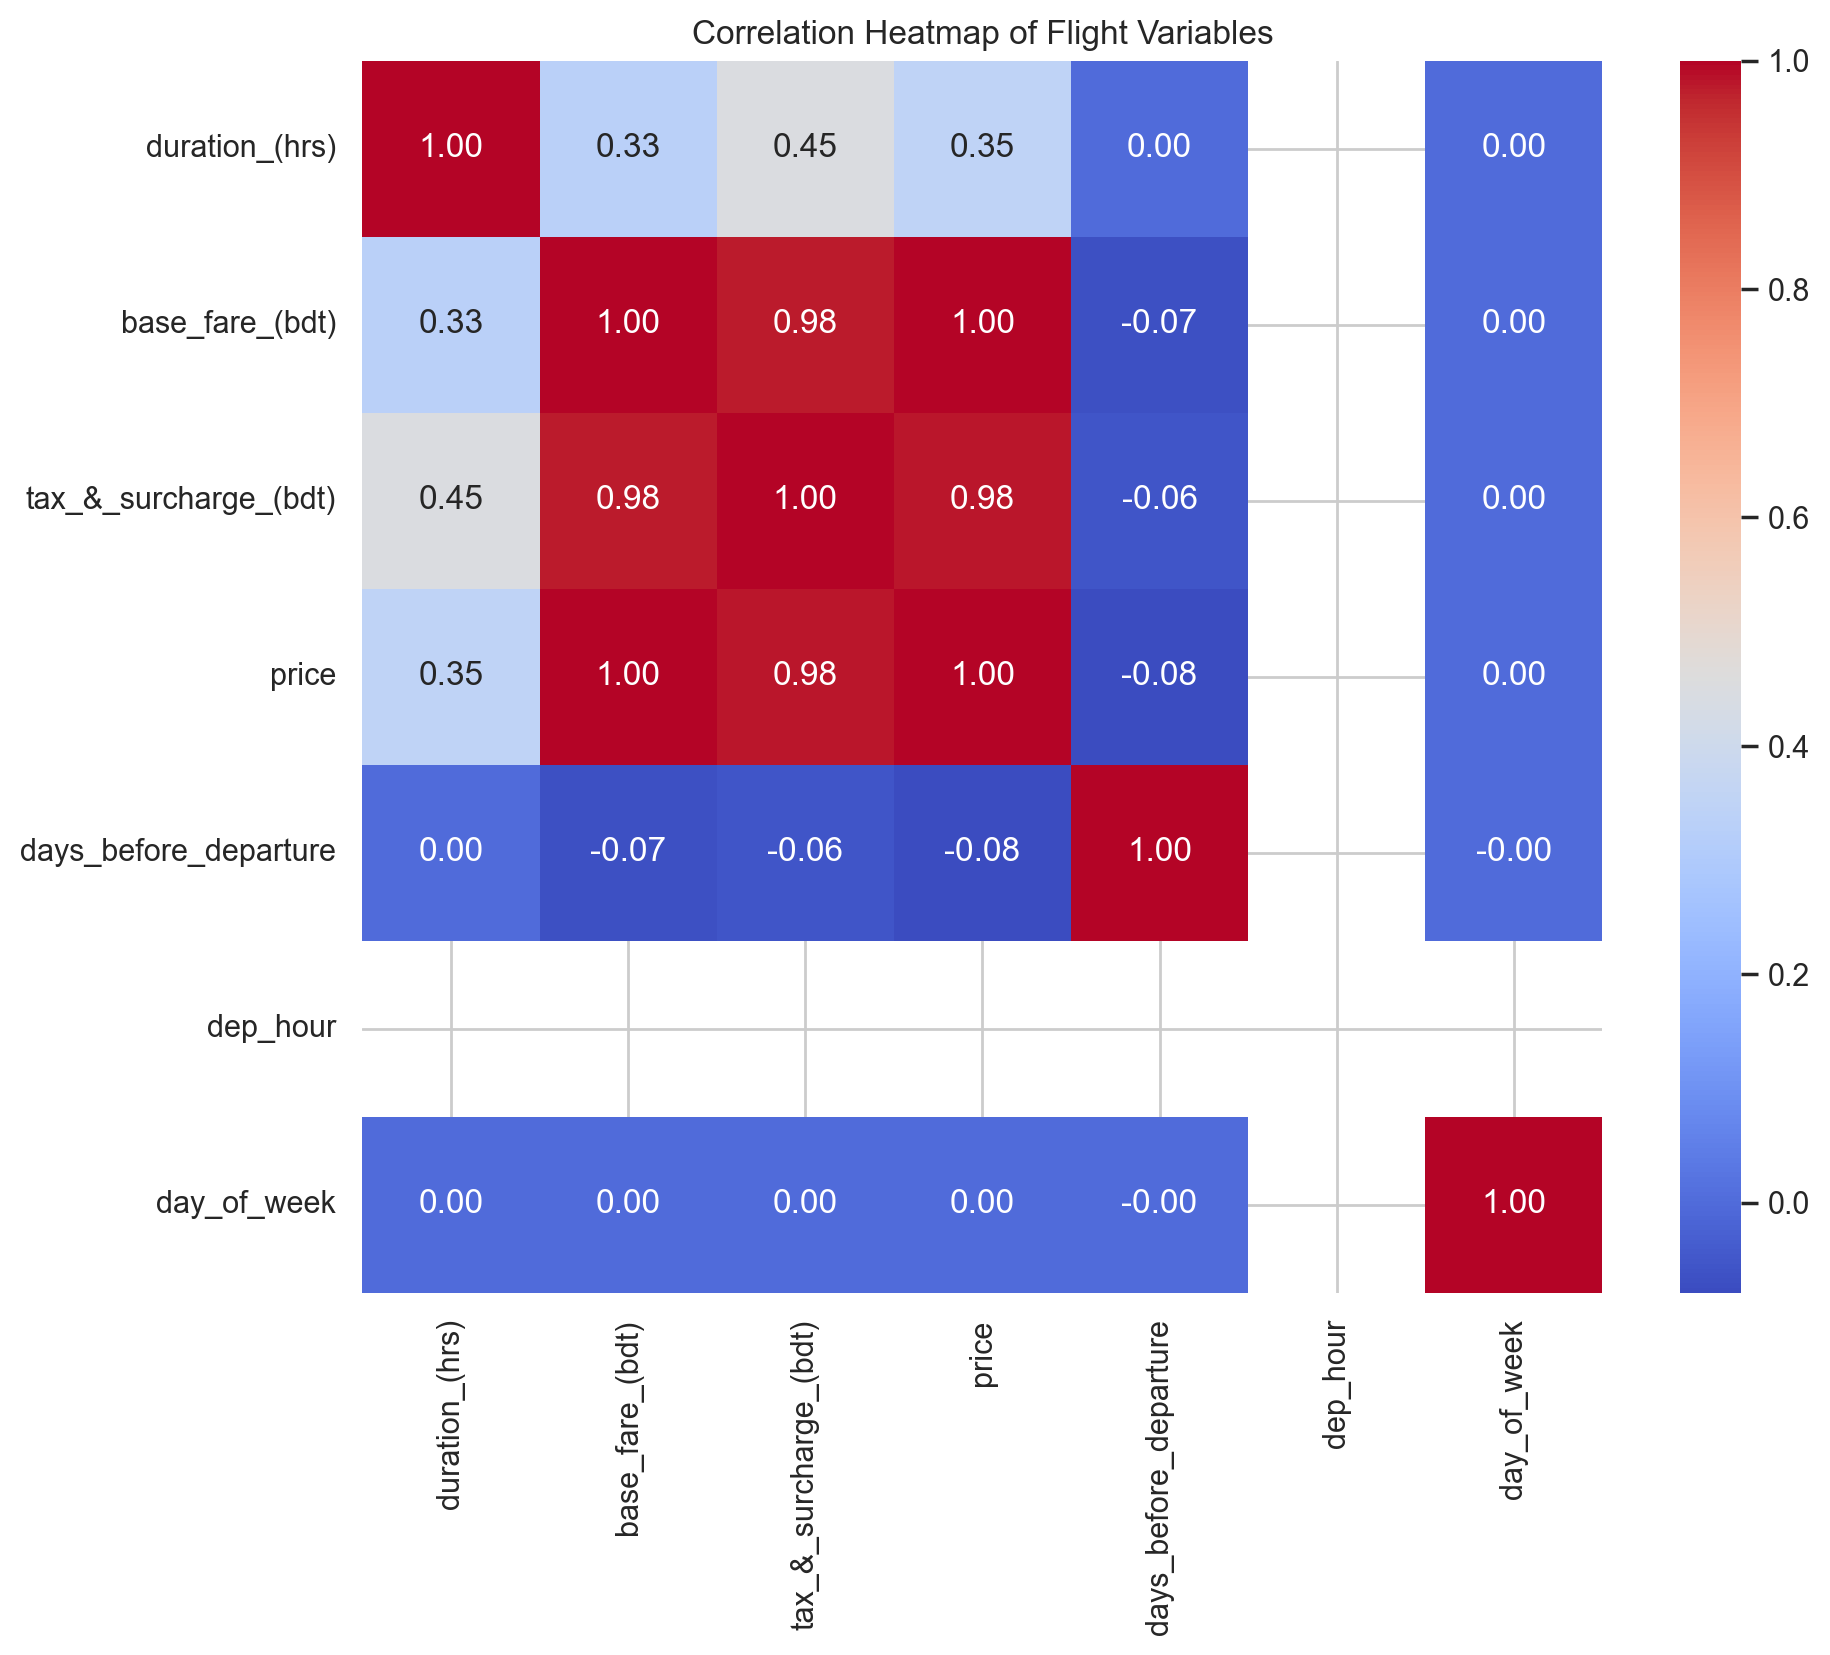

In [7]:
capstone_group11.plot_correlation_heatmap(df_final)

**Analysis & Insights:**

* **Dominant Price Factors:** The strongest correlation exists between `Price`, `Base Fare` (1.00), and `Tax & Surcharge` (0.98). This confirms that total fare is a direct sum of these components and they move in perfect unison.
* **Flight Duration:** There is a moderate positive correlation (**0.35**) between `Duration` and `Price`. This indicates that flight length is a genuine driver of cost—longer flights are generally more expensive.
* **Booking Window Influence:** The variable `Days Before Departure` shows a weak negative correlation (**-0.08**) with `Price`. This supports the hypothesis that booking earlier (more days before) results in slightly lower fares, though the relationship is not strongly linear.
* **Temporal Features:** The `Day of Week` has a correlation of **0.00**, suggesting that the specific day of travel has no linear impact on price in this view.
* **Data Quality Note:** The `Departure Hour (dep_hour)` row is blank/white. This indicates the variable likely contains non-numeric data or null values that prevented the calculation, signaling a need for further data conversion in the cleaning step.

### Visualization 5: Plot Days Before Departure vs Price

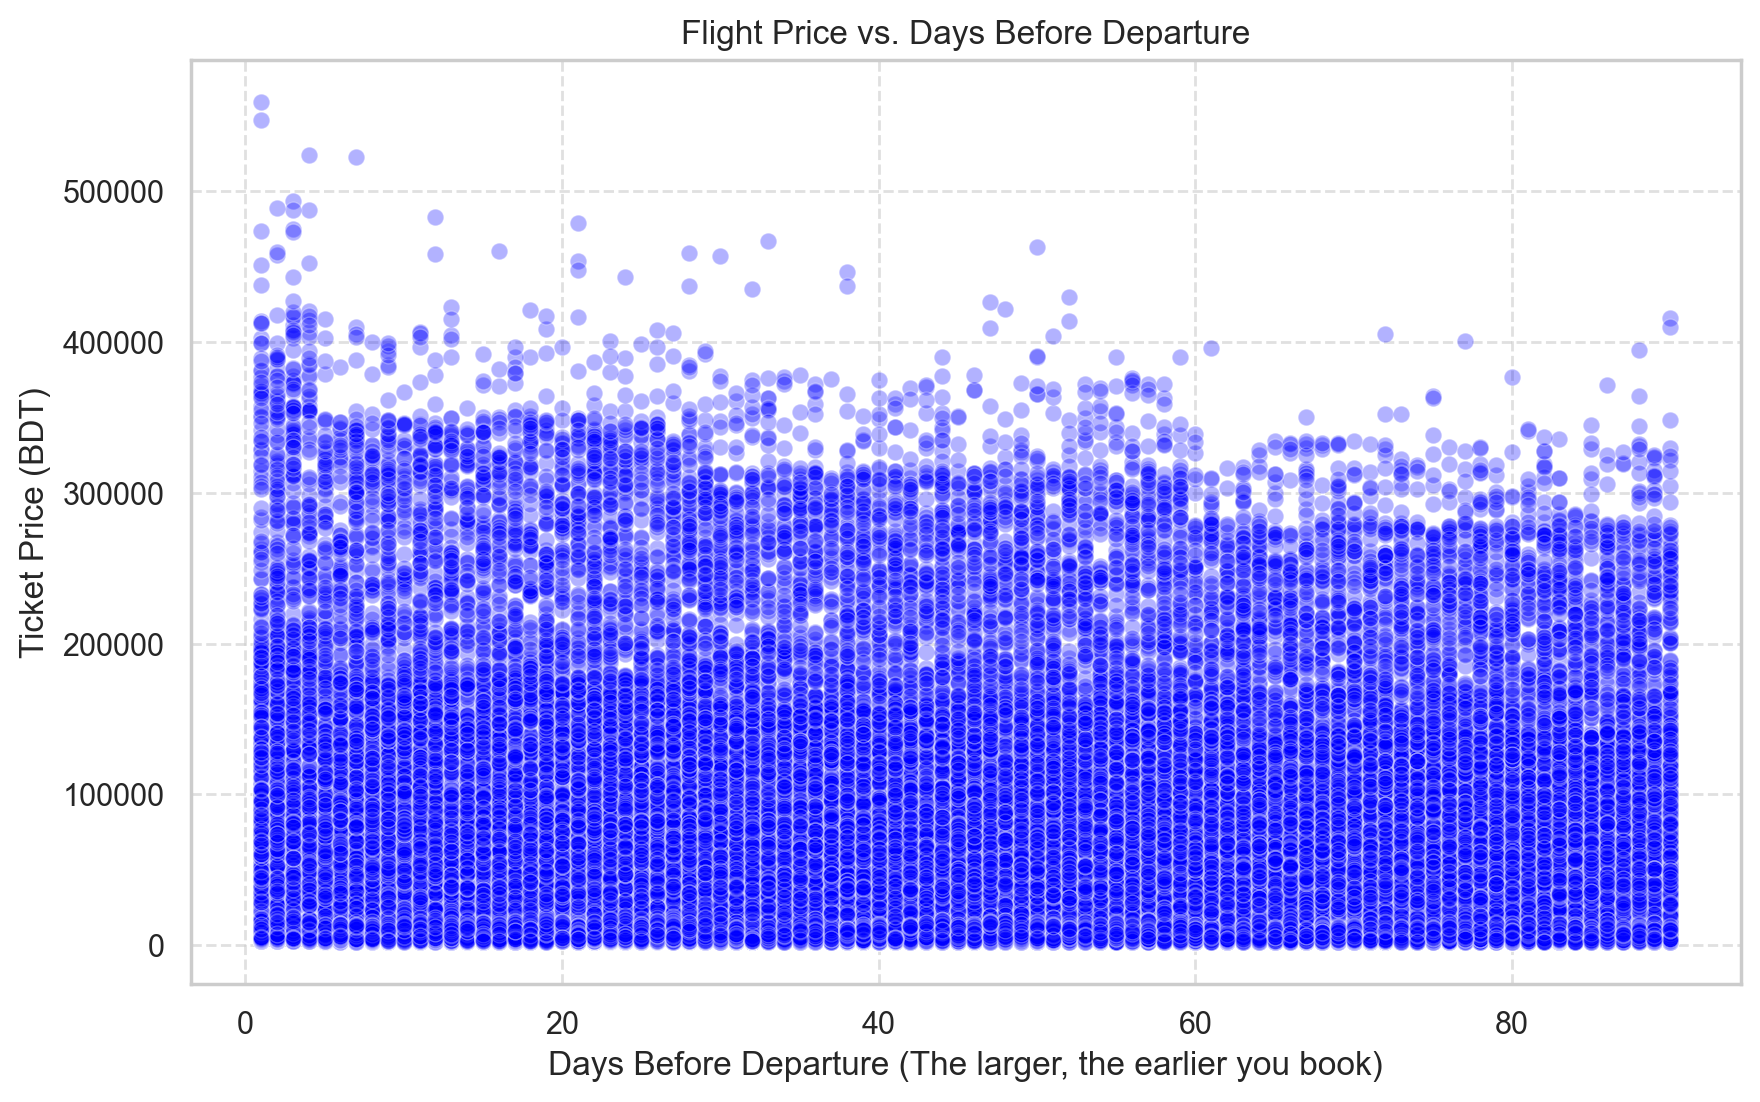

In [8]:
capstone_group11.plot_days_vs_price(df_final)

**Analysis & Insights:**

* **Last-Minute Price Spikes:** The highest ticket prices (reaching above 500,000 BDT) are heavily concentrated in the **0–10 days** range. This indicates that booking very close to the departure date carries the highest risk of encountering extreme price surges.
* **Decreasing Price Ceiling:** As the "Days Before Departure" increases (moving right on the X-axis), the maximum price observed gradually drops. By the **80–90 day** mark, the most expensive tickets rarely exceed 350,000–400,000 BDT, showing that booking early caps the potential maximum cost.
* **Consistent Base Fares:** Interestingly, there is a dense cluster of lower-priced tickets (below 200,000 BDT) that remains consistent across the entire timeline. This suggests that while last-minute bookings can be expensive, economy or base-level tickets are often still available regardless of when the booking is made.
* **Overall Trend:** The data exhibits a **negative correlation** between days before departure and the upper range of prices. While booking early does not guarantee the absolute lowest fare, it significantly protects travelers from the high-cost outliers seen in last-minute purchases.

### Visualization 6: Plot Price Distribution by Class

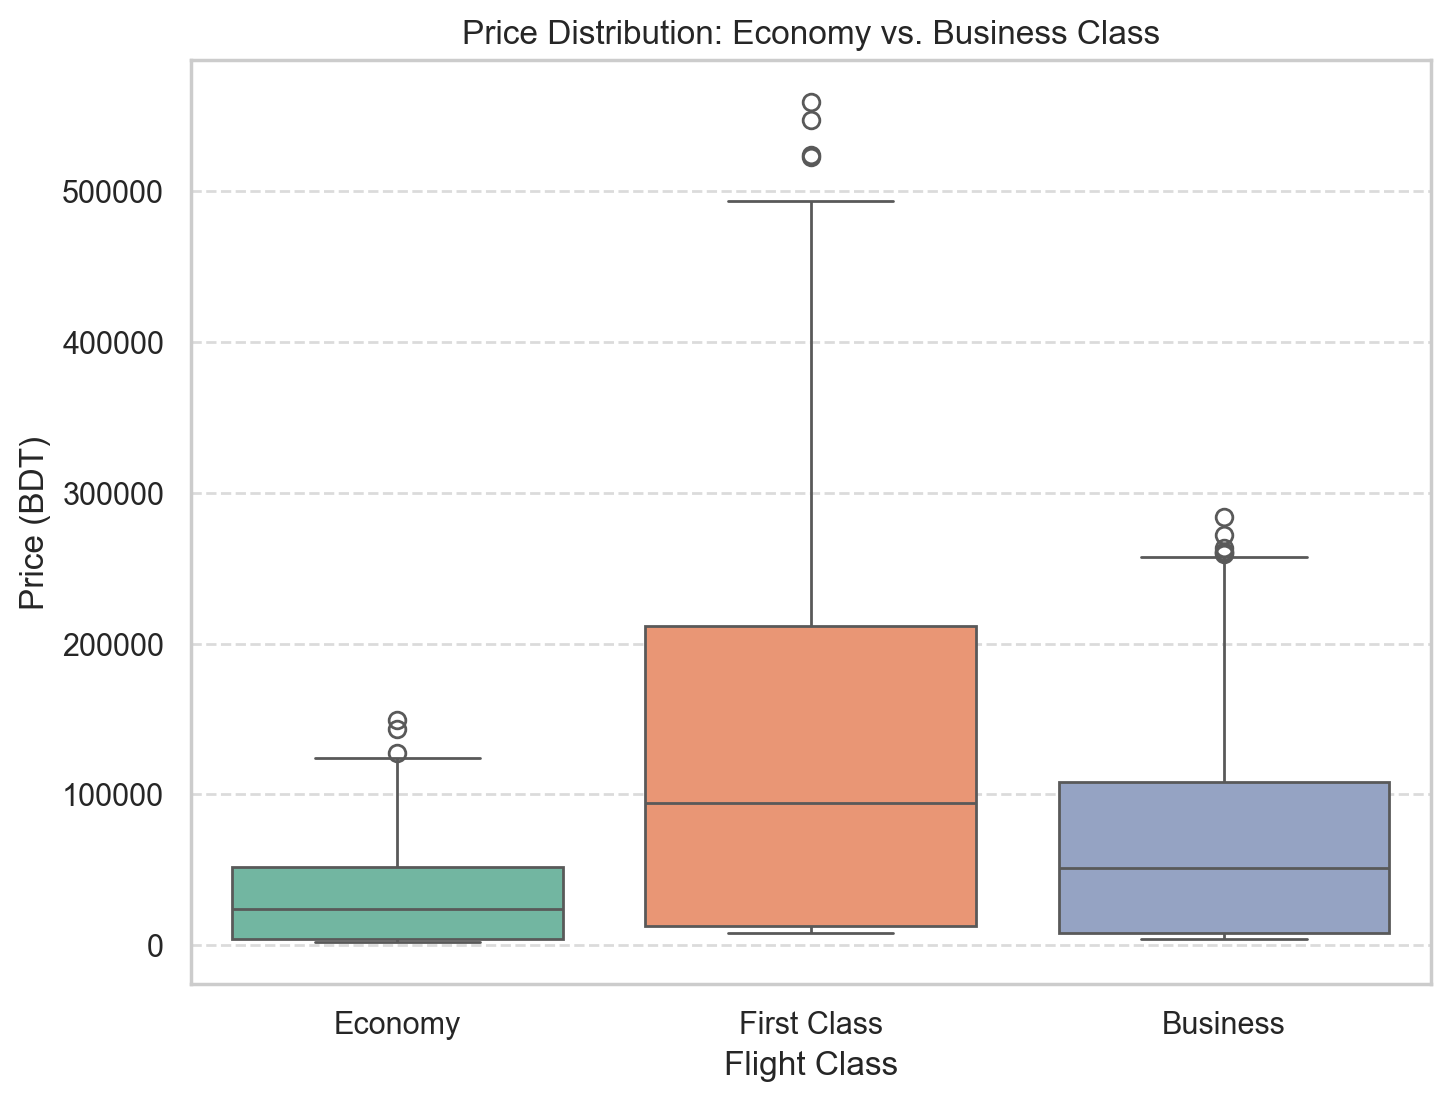

In [9]:
capstone_group11.plot_class_price_distribution(df_final)

**Analysis & Insights:**

* **Distinct Price Hierarchy:** The chart confirms a clear hierarchy where **First Class** is the most expensive, followed by **Business Class**, with **Economy Class** being the cheapest option.
* **Extreme Volatility in First Class:** First Class exhibits the widest price range (tallest box and whiskers), stretching from relatively low fares to highs exceeding **500,000 BDT**. This indicates massive variability in pricing for top-tier tickets.
* **Stability of Economy:** Economy Class has the shortest box and whiskers, showing the most consistent and predictable pricing structure with a low median price.
* **Business Class Positioning:** Business Class sits as a middle ground. While significantly more expensive than Economy, its maximum prices (around 250,000 BDT) are still roughly half the peak cost of First Class.
* **Outliers:** All three classes feature high-price outliers (represented by the circles), but the outliers in First Class represent the absolute highest costs in the entire dataset.

# **Predictive Models (Statistical/Predictive Analysis)**

## Model 1: Linear Regression

--- Starting Linear Regression Training ---
Encoding categorical data...
------------------------------
Model Performance:
R-squared (R2): 0.5701
Mean Squared Error (MSE): 2865820009
------------------------------


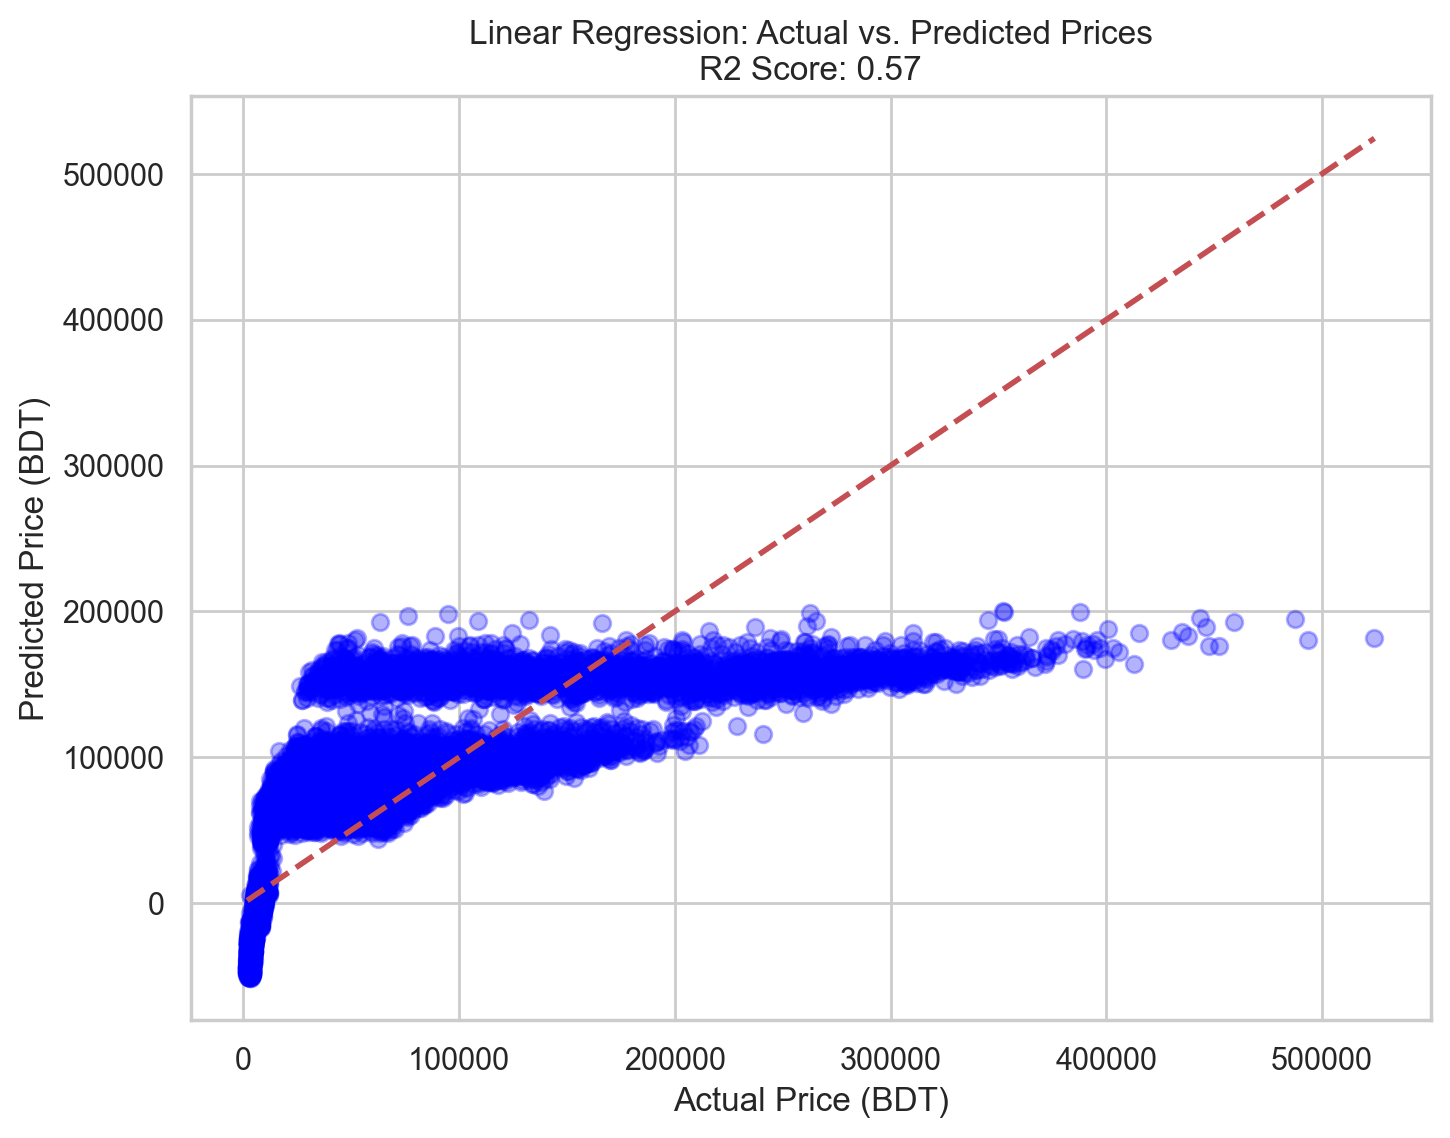

In [10]:
lr_model = capstone_group11.train_linear_regression(df_final)

**Analysis & Insights:**

* **Method Justification:** We selected Multiple Linear Regression as our baseline model to establish a benchmark. Its primary purpose was to test if flight prices share a simple, linear relationship with features like "Days Before Departure" and "Flight Class" before moving to more complex non-linear models.
* **Model Performance ($R^2$):** The model achieved an **$R^2$ score of 0.57**. This indicates that our linear model explains approximately **57% of the variability** in ticket prices. While statistically significant, it leaves 43% of the variance unexplained, suggesting that price factors are too complex for a straight line to capture fully.
* **Visual Analysis (Actual vs. Predicted):**
    * **The Ceiling Effect:** The scatter plot reveals a critical limitation. While the model predicts lower fares (0–100,000 BDT) reasonably well (clustering near the red dashed line), it completely fails to predict high-end tickets. The predictions "flatline" or cap out at approximately **200,000 BDT**, even when actual prices reach **500,000 BDT**.
    * **Underestimation:** For expensive flights (likely Business or First Class), the model systematically underestimates the price, causing the blue points to drift far to the right of the red perfection line.
    * **Negative Predictions:** A cluster of points at the bottom left drops below zero. Since ticket prices cannot be negative, this confirms that a simple linear equation is mathematically forced to make impossible predictions for certain low-fare combinations.
* **Conclusion:** The moderate $R^2$ and the visual "plateau" confirm that while linear regression captures basic trends, it lacks the complexity to model high-value outliers. This validates our decision to use the **Random Forest Regressor** as our next step to capture these non-linear patterns.

## Model 2: Random Forest

In [11]:
# Reload the module to ensure the latest changes in the .py file are recognized by Jupyter
import importlib
import capstone_group11
importlib.reload(capstone_group11)

# Ensure pandas is imported for data handling
import pandas as pd 

print("✅ Module 'capstone_group11' has been reloaded successfully.")

✅ Module 'capstone_group11' has been reloaded successfully.


Data prepared for regression. Feature shape: (57000, 77)

=== Regression Model Performance ===
Linear Regression: R2 Score = 0.5701, RMSE = 53533.34
Random Forest: R2 Score = 0.6758, RMSE = 46486.18


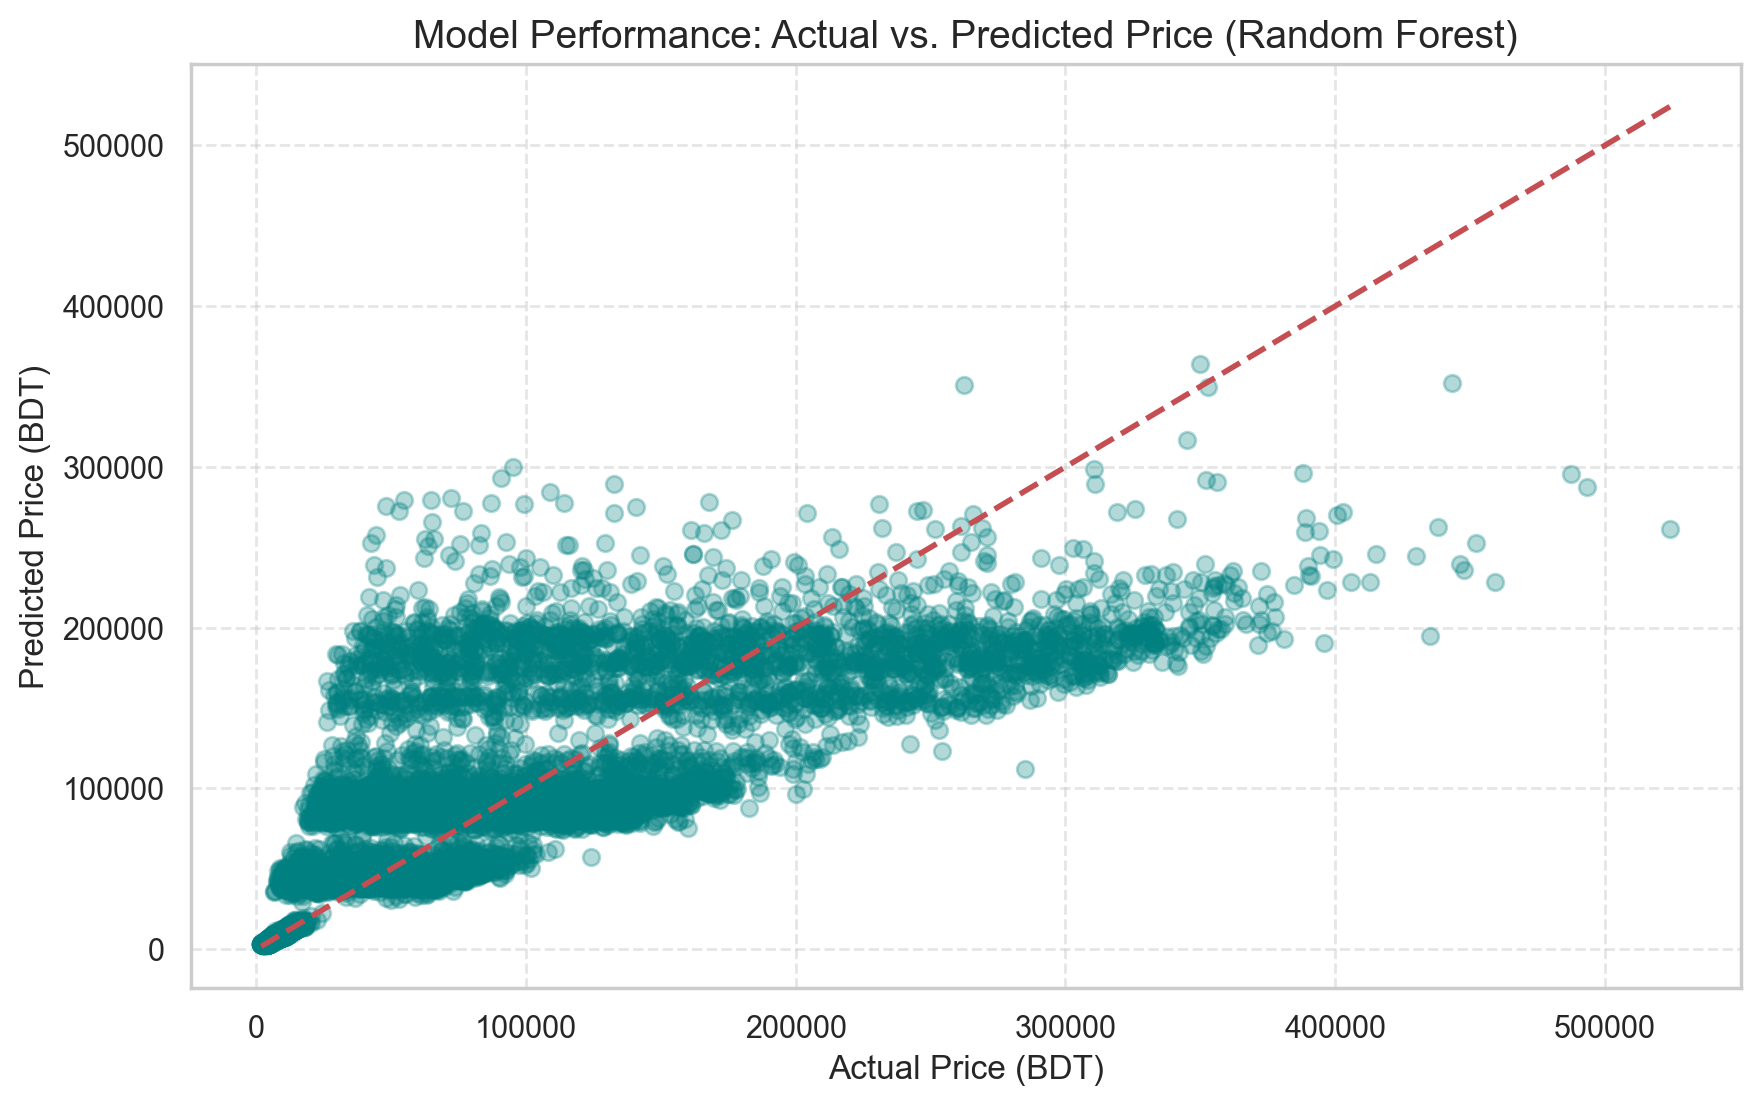

In [12]:
# --- Phase 2: Predictive Modeling (Regression) ---
# Goal: Predict 'price' based on flight features

# 1. Data Preparation (Encoding categorical variables and splitting the dataset)
# Using the prepare_data_for_model function with the task set to 'regression'
X_train_reg, X_test_reg, y_train_reg, y_test_reg = capstone_group11.prepare_data_for_model(
    df_final, 
    target_col='price', 
    task='regression'
)

# 2. Model Training and Evaluation
# This executes the training pipeline for multiple regression models
reg_results = capstone_group11.train_regression_models(
    X_train_reg, X_test_reg, y_train_reg, y_test_reg
)

# 3. Display Performance Results
print("\n=== Regression Model Performance ===")
for model_name, metrics in reg_results.items():
    print(f"{model_name}: R2 Score = {metrics['R2']:.4f}, RMSE = {metrics['RMSE']:.2f}")

# 4. (Optional) Visualization: Actual vs. Predicted Values (Random Forest Example)
import matplotlib.pyplot as plt

# Extract the trained model and generate predictions
best_model = reg_results['Random Forest']['model']
y_pred_best = best_model.predict(X_test_reg)

plt.figure(figsize=(10, 6))
# Scatter plot of predictions vs actual values
plt.scatter(y_test_reg, y_pred_best, alpha=0.3, color='teal')
# Reference line (Perfect prediction where Actual = Predicted)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)

plt.xlabel('Actual Price (BDT)')
plt.ylabel('Predicted Price (BDT)')
plt.title('Model Performance: Actual vs. Predicted Price (Random Forest)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Model 3: Decision Tree

Data prepared for classification. Feature shape: (57000, 76)
Decision Tree Accuracy: 0.7560
Classification Report:
               precision    recall  f1-score   support

    Business       0.72      0.64      0.68      3771
     Economy       0.69      0.94      0.80      3790
 First Class       0.91      0.69      0.78      3839

    accuracy                           0.76     11400
   macro avg       0.77      0.76      0.75     11400
weighted avg       0.77      0.76      0.75     11400



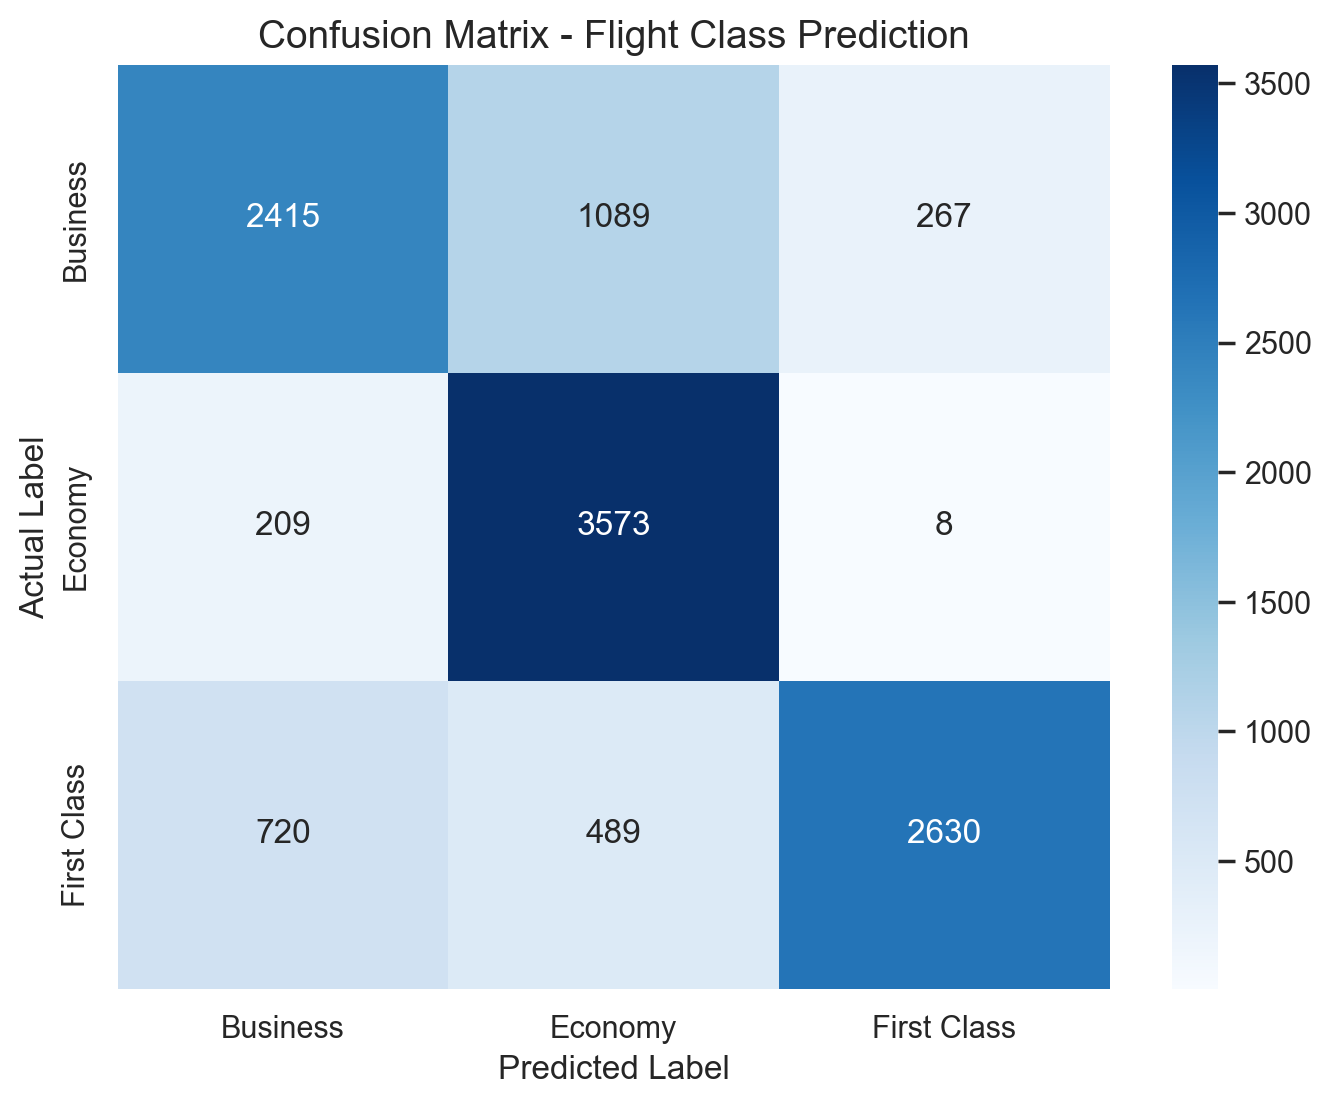

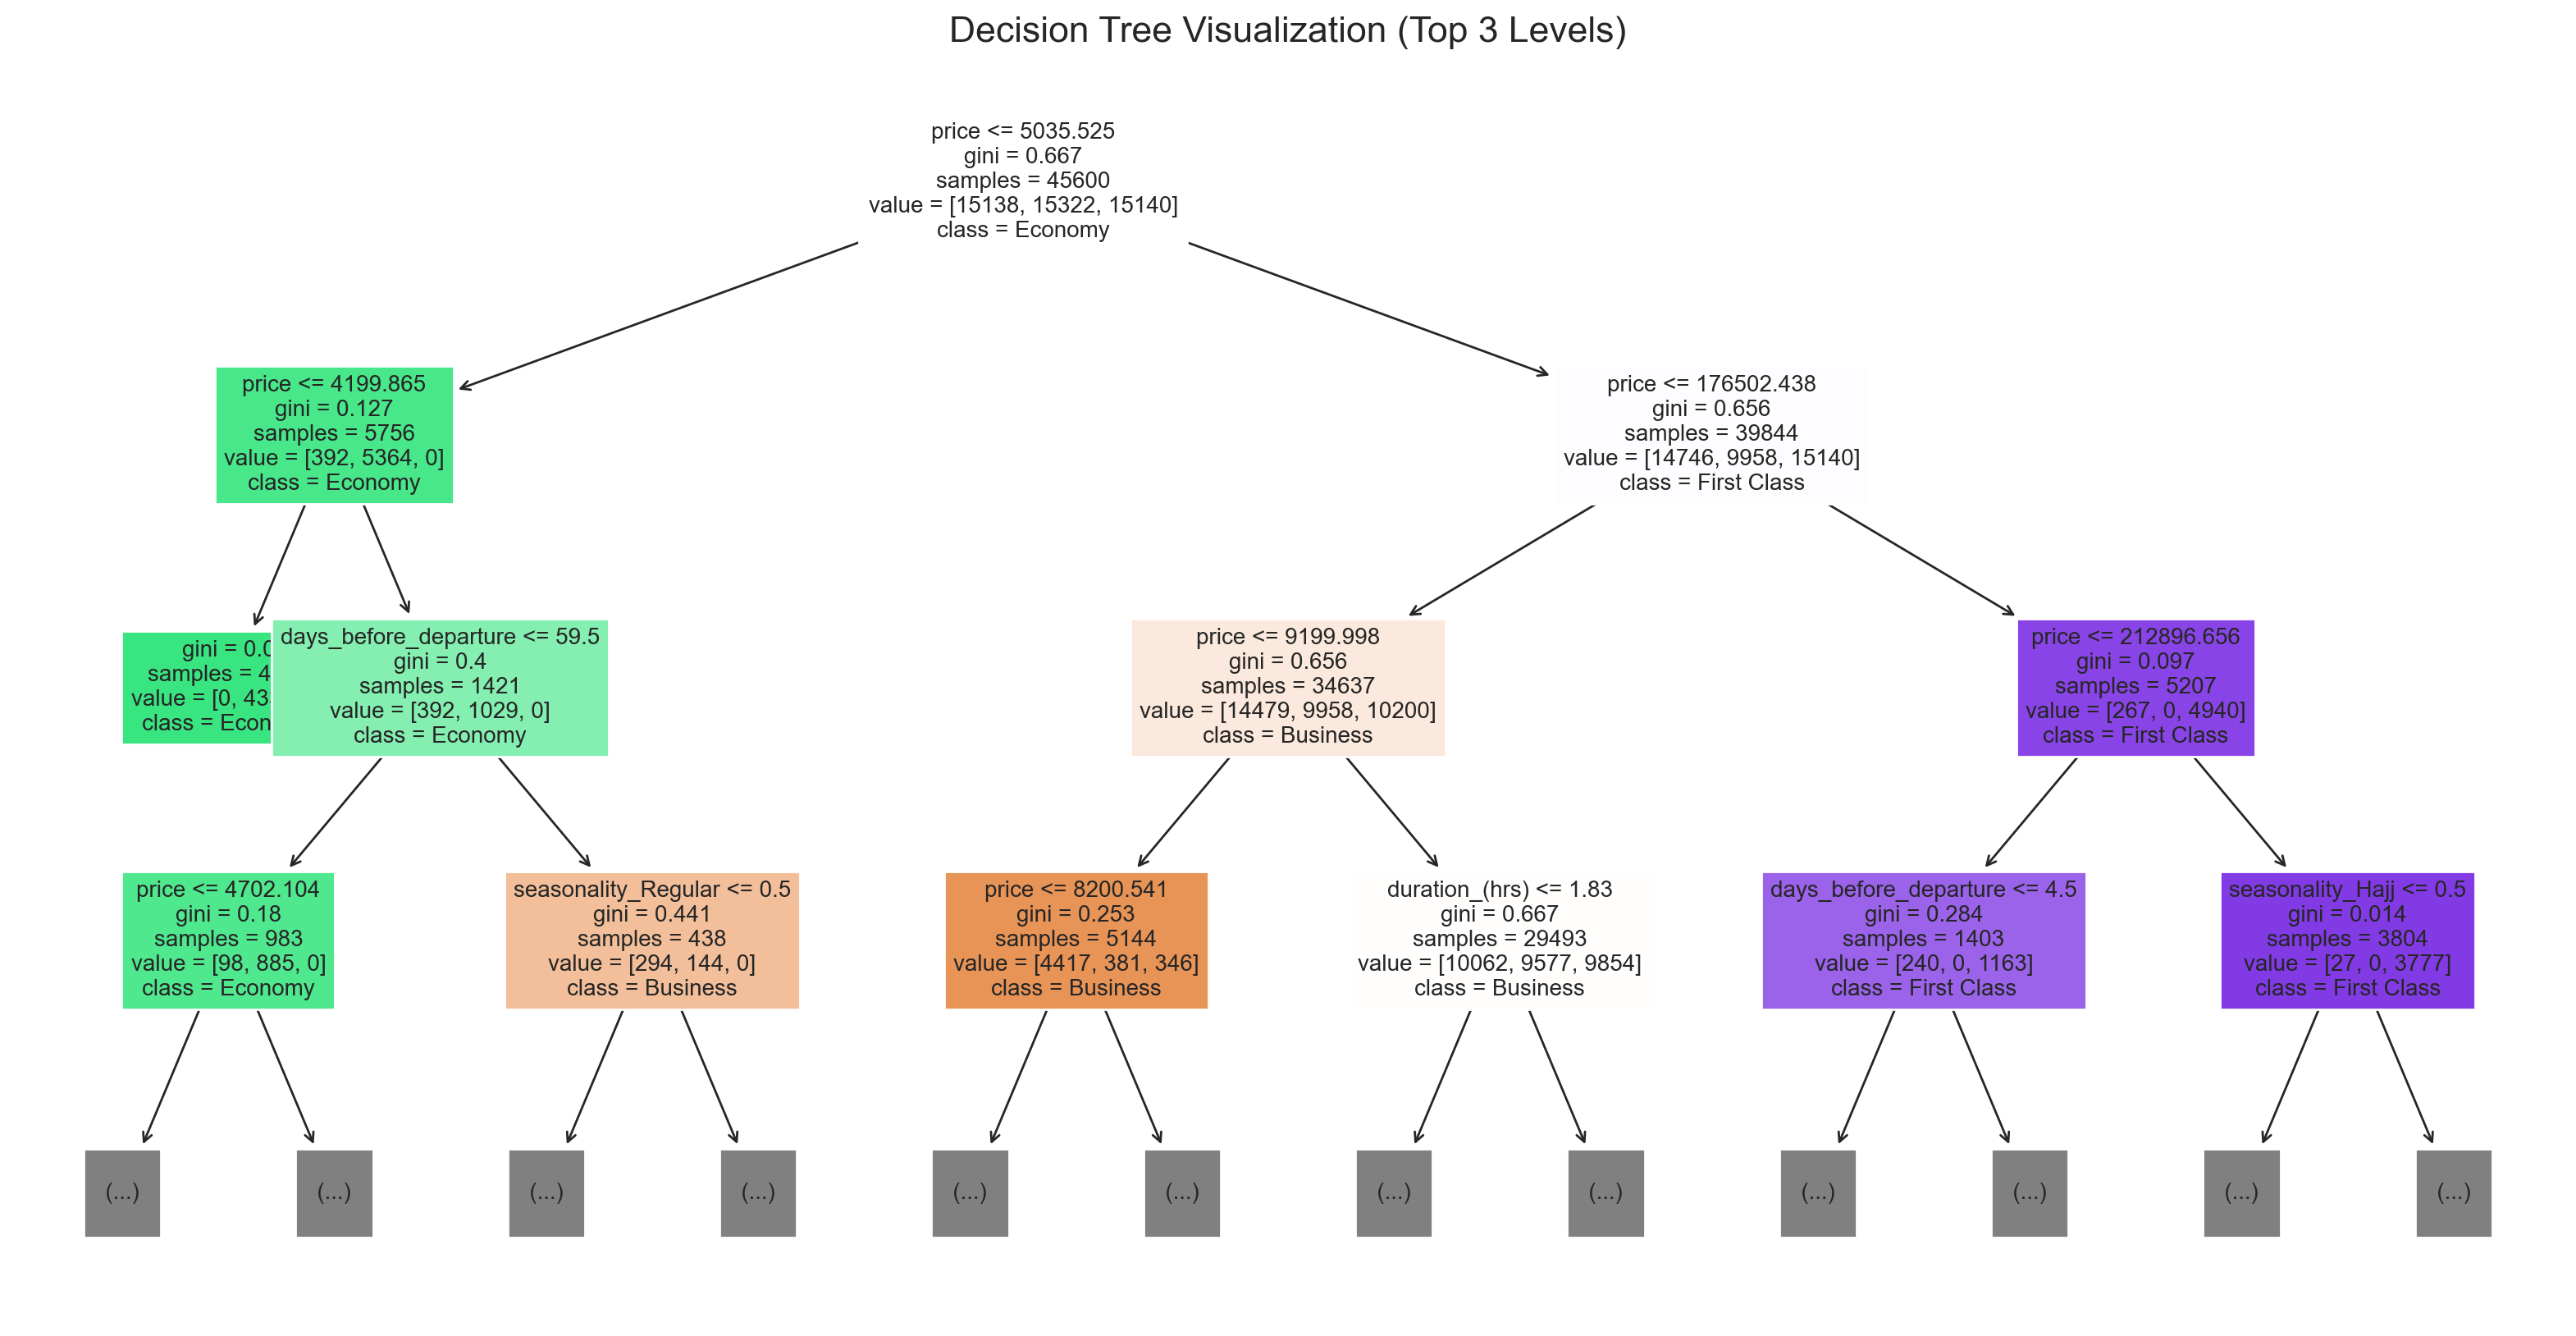

In [13]:
# --- Phase 2: Predictive Modeling (Classification) ---
# Goal: Predict the flight cabin class (e.g., 'Economy' vs 'Business')

# 1. Data Preparation
# Note: Here, the target_col is set to 'class' for classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = capstone_group11.prepare_data_for_model(
    df_final, 
    target_col='class', 
    task='classification'
)

# 2. Model Training
# This returns the trained Decision Tree model and the resulting Confusion Matrix
dt_model, cm = capstone_group11.train_classification_model(X_train_clf, X_test_clf, y_train_clf, y_test_clf)

# 3. Visualize the Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# 'annot=True' shows the counts, 'fmt=d' ensures they are displayed as integers
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=dt_model.classes_, 
            yticklabels=dt_model.classes_)

plt.title('Confusion Matrix - Flight Class Prediction', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show()

# 4. Visualize the Decision Tree (Partial view for clarity)
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
# 'max_depth=3' limits the tree size to keep the visualization readable
plot_tree(dt_model, 
          feature_names=list(X_train_clf.columns), 
          class_names=list(dt_model.classes_), 
          filled=True, 
          max_depth=3, 
          fontsize=10)

plt.title('Decision Tree Visualization (Top 3 Levels)', fontsize=16)
plt.show()

# **Interpretation & Conclusions**

# **References**